# Análisis Red Corrupción Ficticia

## Configuración e importaciones

In [ ]:
%pip install networkx matplotlib pandas python-louvain

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 15.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 31.3 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 41.0 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 51.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 26.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 51.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 48.8 MB/s  0:00:00
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9459 sha256=237516b3fb265b7472d7331dfebc469d82a18fd8606201b8730d277a874b1fa3
  Stored in directory: /home/codespace/.cache/pip/wheels/40/f1/e3/485b698c520fa0baee1d07897abc7b8d6479b7d199ce96f4af
Successfully built python-louvain
  

In [9]:
import pandas as pd
import random
from datetime import datetime, timedelta
import networkx as nx
import community as community_louvain
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

## Generar CSV

In [4]:
# 1. Definición estática de Nodos con sus Roles y Comunidades para garantizar consistencia
nodos_info = {
    # Comunidad: GABINETE
    'MIN_PALPATINE': ('POLITICO', 'GABINETE'),
    'ASE_TARKIN': ('ASESOR', 'GABINETE'),
    'ASE_THRAWN': ('ASESOR', 'GABINETE'),
    'POL_VALORUM': ('POLITICO', 'GABINETE'),
    'POL_PADME': ('POLITICO', 'GABINETE'),
    'ASE_PESTAGE': ('ASESOR', 'GABINETE'),
    'ASE_DOOKU': ('ASESOR', 'GABINETE'),
    
    # Comunidad: COMPRAS
    'FUN_KRENNIC': ('FUNCIONARIO', 'COMPRAS'),
    'FUN_HOFF': ('FUNCIONARIO', 'COMPRAS'),
    'FUN_JERJERROD': ('FUNCIONARIO', 'COMPRAS'),
    'FUN_GRIEVOUS': ('FUNCIONARIO', 'COMPRAS'),
    'FUN_OURO': ('FUNCIONARIO', 'COMPRAS'),
    
    # Comunidad: FISCALIZACION
    'FUN_PIETT': ('FUNCIONARIO', 'FISCALIZACION'),
    'FUN_YULAREN': ('FUNCIONARIO', 'FISCALIZACION'),
    'FUN_NEEDA': ('FUNCIONARIO', 'FISCALIZACION'),
    
    # Comunidad: INTERMEDIARIOS (El nexo crucial)
    'INT_BOBA_FETT': ('INTERMEDIARIO', 'INTERMEDIARIOS'), # NODO PUENTE PRINCIPAL
    'INT_CAD_BANE': ('INTERMEDIARIO', 'INTERMEDIARIOS'),
    'INT_GREEDO': ('INTERMEDIARIO', 'INTERMEDIARIOS'),
    'INT_ZAM_WESELL': ('INTERMEDIARIO', 'INTERMEDIARIOS'),
    'CON_FETT_JANGO': ('CONTACTO', 'INTERMEDIARIOS'),
    
    # Comunidad: PROVEEDORES
    'EMP_VADER': ('EMPRESARIO', 'PROVEEDORES'),
    'EMP_XIZOR': ('EMPRESARIO', 'PROVEEDORES'),
    'EMP_GUNRAY': ('EMPRESARIO', 'PROVEEDORES'),
    'EMP_RENN': ('EMPRESARIO', 'PROVEEDORES'),
    'CON_JABBA': ('CONTACTO', 'PROVEEDORES'),
    'CON_LANDO': ('CONTACTO', 'PROVEEDORES'),
    'CON_MAUL': ('CONTACTO', 'PROVEEDORES'),
}

# 2. Listas de categorías permitidas según las especificaciones de la imagen
tipos_relacion_monetaria = ['TRANSFERENCIA', 'ADJUDICACION']
tipos_relacion_no_monetaria = ['REUNION', 'LLAMADA', 'MENSAJE', 'FAVOR', 'ENCUBRIMIENTO', 'PRESION']

comentarios_opciones = [
    "Coordinación de bases de licitación.",
    "Llamada telefónica fuera de horario laboral.",
    "Transferencia de fondos a cuenta externa.",
    "Reunión informal en cafetería céntrica.",
    "Presión indebida para acelerar firma.",
    "Mensaje encriptado detectado por auditoría.",
    "Adjudicación directa sin concurso público.",
    "Favor político solicitado con urgencia.",
    "Encubrimiento de faltas administrativas.",
    "Modificación de contrato a última hora."
]

# Base de fechas coherente
fecha_base = datetime(2026, 1, 1)

aristas = []
aristas_creadas = set()
id_contador = 1

def agregar_arista(origen, destino, tipo=None, riesgo=None, peso=None):
    global id_contador
    if origen == destino or (origen, destino) in aristas_creadas:
        return
    
    rol_orig, com_orig = nodos_info[origen]
    rol_dest, com_dest = nodos_info[destino]
    
    if tipo is None:
        # 70% relaciones normales, 30% financieras si es con proveedores
        if 'PROVEEDORES' in [com_orig, com_dest] or 'INTERMEDIARIOS' in [com_orig, com_dest]:
            tipo = random.choice(tipos_relacion_monetaria + tipos_relacion_no_monetaria)
        else:
            tipo = random.choice(tipos_relacion_no_monetaria)
            
    if peso is None:
        peso = random.randint(1, 5)
        
    if riesgo is None:
        # Mayor probabilidad de riesgo en transacciones o presiones
        riesgo = 1 if tipo in ['TRANSFERENCIA', 'ADJUDICACION', 'ENCUBRIMIENTO', 'PRESION'] and random.random() > 0.4 else 0

    # Cumplir regla: Monto = 0 si no es monetaria
    monto = random.randint(15, 100) if tipo in tipos_relacion_monetaria else 0
    
    fecha = (fecha_base + timedelta(days=random.randint(0, 90))).strftime('%Y-%m-%d')
    comentario = random.choice(comentarios_opciones)
    id_arista = f"E{id_contador:03d}"
    
    aristas.append({
        'id_arista': id_arista,
        'origen': origen,
        'destino': destino,
        'rol_origen': rol_orig,
        'rol_destino': rol_dest,
        'comunidad_origen': com_orig,
        'comunidad_destino': com_dest,
        'tipo_relacion': tipo,
        'peso': peso,
        'monto': monto,
        'fecha': fecha,
        'riesgo': riesgo,
        'comentario': comentario
    })
    
    aristas_creadas.add((origen, destino))
    id_contador += 1

# --- CONSTRUCCIÓN DIRIGIDA DE LA ESTRUCTURA DE LA RED ---

# A. Conexiones del núcleo político (Gabinete e Institución)
politicos = [n for n, info in nodos_info.items() if info[1] == 'GABINETE']
funcionarios_compras = [n for n, info in nodos_info.items() if info[1] == 'COMPRAS']
fiscalizadores = [n for n, info in nodos_info.items() if info[1] == 'FISCALIZACION']
proveedores = [n for n, info in nodos_info.items() if info[1] == 'PROVEEDORES']

for p in politicos:
    for f in funcionarios_compras:
        if random.random() > 0.3:
            agregar_arista(p, f, tipo='PRESION', riesgo=1) # Presión de políticos a compras

for f in funcionarios_compras:
    for fi in fiscalizadores:
        if random.random() > 0.4:
            agregar_arista(f, fi, tipo='ENCUBRIMIENTO', riesgo=random.choice([0, 1]))

# B. El Puente Crítico: INT_BOBA_FETT opera conectando ambos mundos
# Conexiones con el sector gubernamental (Alta centralidad de intermediación)
agregar_arista('MIN_PALPATINE', 'INT_BOBA_FETT', tipo='LLAMADA', peso=4, riesgo=1)
agregar_arista('ASE_TARKIN', 'INT_BOBA_FETT', tipo='REUNION', peso=3, riesgo=0)
agregar_arista('INT_BOBA_FETT', 'FUN_KRENNIC', tipo='FAVOR', peso=5, riesgo=1)
agregar_arista('INT_BOBA_FETT', 'FUN_PIETT', tipo='MENSAJE', peso=2, riesgo=0)

# Conexiones con el sector privado / proveedores
agregar_arista('EMP_VADER', 'INT_BOBA_FETT', tipo='TRANSFERENCIA', peso=5, riesgo=1)
agregar_arista('EMP_XIZOR', 'INT_BOBA_FETT', tipo='TRANSFERENCIA', peso=4, riesgo=1)
agregar_arista('INT_BOBA_FETT', 'CON_JABBA', tipo='REUNION', peso=4, riesgo=1)

# C. Conexiones internas de la red de Proveedores y otros intermediarios
for prov in proveedores:
    for f_comp in funcionarios_compras:
        if random.random() > 0.6:
            agregar_arista(f_comp, prov, tipo='ADJUDICACION', riesgo=1) # Adjudicaciones directas de riesgo
            agregar_arista(prov, f_comp, tipo='TRANSFERENCIA', riesgo=1) # Retornos monetarios

# Rellenar con otras interacciones aleatorias controladas hasta alcanzar la cuota (~85 aristas)
todos_nodos = list(nodos_info.keys())
while len(aristas) < 85:
    u = random.choice(todos_nodos)
    v = random.choice(todos_nodos)
    agregar_arista(u, v)

# 3. Conversión a DataFrame, verificación de cuotas y exportación
df_aristas = pd.DataFrame(aristas)

print("=== VERIFICACIÓN DE REQUERIMIENTOS ===")
print(f"Número de nodos únicos en el dataset: {len(set(df_aristas['origen']).union(set(df_aristas['destino'])))}")
print(f"Número total de aristas generadas: {len(df_aristas)}")
print(f"Número de relaciones con flag_riesgo = 1: {df_aristas['riesgo'].sum()}")
print(f"Roles únicos de origen presentes: {df_aristas['rol_origen'].nunique()}")
print(f"Comunidades únicas de origen presentes: {df_aristas['comunidad_origen'].nunique()}")

# Guardar a archivo CSV en formato UTF-8 tal como se exige
filename = "Luengo_Antonia_T2.csv"
df_aristas.to_csv(filename, index=False, encoding='utf-8')
print(f"\nArchivo '{filename}' generado.")

=== VERIFICACIÓN DE REQUERIMIENTOS ===
Número de nodos únicos en el dataset: 26
Número total de aristas generadas: 85
Número de relaciones con flag_riesgo = 1: 71
Roles únicos de origen presentes: 6
Comunidades únicas de origen presentes: 4

Archivo 'Luengo_Antonia_T2.csv' generado.


## Construcción del Grafo, Métricas y Detección de Comunidades

### Procesamiento y cálculo de métricas

In [3]:
# 1. Cargar el dataset
df_aristas = pd.read_csv("Luengo_Antonia_T2.csv", encoding='utf-8')

# 2. Construir el grafo dirigido
G = nx.from_pandas_edgelist(
    df_aristas, 
    source='origen', 
    target='destino', 
    edge_attr=['id_arista', 'rol_origen', 'rol_destino', 'tipo_relacion', 'peso', 'monto', 'fecha', 'riesgo', 'comentario'],
    create_using=nx.DiGraph()
)

# 3. Asignar atributos de rol y comunidad original
nodos_atributos = {}
for _, row in df_aristas.iterrows():
    nodos_atributos[row['origen']] = {'rol': row['rol_origen'], 'comunidad_origen': row['comunidad_origen']}
    nodos_atributos[row['destino']] = {'rol': row['rol_destino'], 'comunidad_origen': row['comunidad_destino']}
nx.set_node_attributes(G, nodos_atributos)

# 4. Cálculo de Métricas Globales
num_nodos = G.number_of_nodes()
num_aristas = G.number_of_edges()
densidad = nx.density(G)

# 5. Cálculo de Centralidades
degree_centrality = nx.degree_centrality(G)
in_degree_centrality = nx.in_degree_centrality(G)
out_degree_centrality = nx.out_degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, normalized=True)
closeness_centrality = nx.closeness_centrality(G)

# Guardar atributos en el grafo
nx.set_node_attributes(G, degree_centrality, 'degree_centrality')
nx.set_node_attributes(G, betweenness_centrality, 'betweenness_centrality')
nx.set_node_attributes(G, closeness_centrality, 'closeness_centrality')

# 6. Detección de Comunidades (Louvain)
G_no_dirigido = G.to_undirected()
particion_louvain = community_louvain.best_partition(G_no_dirigido, weight='peso')
nx.set_node_attributes(G, particion_louvain, 'comunidad_detectada')

### Tabla de resultados

In [4]:
# Imprimir métricas globales
print("---------------- MÉTRICAS GLOBALES DE LA RED -----------------")
print(f"Número total de Nodos: {num_nodos}")
print(f"Número total de Aristas: {num_aristas}")
print(f"Densidad de la red: {densidad:.4f}")
print(f"Número de comunidades detectadas (Louvain): {len(set(particion_louvain.values()))}")
print("-------------------------------------------------------------\n")
print(f"Promedio In-Degree: {sum(in_degree_centrality.values())/num_nodos:.4f}")
print(f"Promedio Out-Degree: {sum(out_degree_centrality.values())/num_nodos:.4f}")
print(f"Promedio Closeness Centrality: {sum(closeness_centrality.values())/num_nodos:.4f}")
print("=============================================================\n")

# Mostrar el Top 5
def obtener_df_top_5(metrica_dict, nombre_metrica):
    top_5 = sorted(metrica_dict.items(), key=lambda item: item[1], reverse=True)[:5]
    datos = []
    for nodo, valor in top_5:
        datos.append({
            'Nodo': nodo,
            'Valor Métrica': round(valor, 4),
            'Rol': G.nodes[nodo].get('rol', 'Desconocido'),
            'Comunidad Original': G.nodes[nodo].get('comunidad_origen', 'Desconocida'),
            'Comunidad Louvain': G.nodes[nodo].get('comunidad_detectada', 'Desconocida')
        })
    df = pd.DataFrame(datos)
    df.index = range(1, 6)
    return df

print("---------- TOP 5 NODOS POR DEGREE CENTRALITY ----------")
df_degree = obtener_df_top_5(degree_centrality, "Degree Centrality")
display(df_degree)

print("\n---------- TOP 5 NODOS POR BETWEENNESS CENTRALITY ----------")
df_betweenness = obtener_df_top_5(betweenness_centrality, "Betweenness Centrality")
display(df_betweenness)

---------------- MÉTRICAS GLOBALES DE LA RED -----------------
Número total de Nodos: 26
Número total de Aristas: 85
Densidad de la red: 0.1308
Número de comunidades detectadas (Louvain): 5
-------------------------------------------------------------

Promedio In-Degree: 0.1308
Promedio Out-Degree: 0.1308
Promedio Closeness Centrality: 0.2832

---------- TOP 5 NODOS POR DEGREE CENTRALITY ----------


,Nodo,Valor Métrica,Rol,Comunidad Original,Comunidad Louvain
1,FUN_KRENNIC,0.84,FUNCIONARIO,COMPRAS,0
2,FUN_JERJERROD,0.80,FUNCIONARIO,COMPRAS,3
3,FUN_OURO,0.48,FUNCIONARIO,COMPRAS,0
4,FUN_GRIEVOUS,0.44,FUNCIONARIO,COMPRAS,4
5,FUN_HOFF,0.36,FUNCIONARIO,COMPRAS,2



---------- TOP 5 NODOS POR BETWEENNESS CENTRALITY ----------


,Nodo,Valor Métrica,Rol,Comunidad Original,Comunidad Louvain
1,FUN_JERJERROD,0.1624,FUNCIONARIO,COMPRAS,3
2,FUN_KRENNIC,0.1440,FUNCIONARIO,COMPRAS,0
3,CON_MAUL,0.0925,CONTACTO,PROVEEDORES,2
4,FUN_OURO,0.0600,FUNCIONARIO,COMPRAS,0
5,EMP_RENN,0.0578,EMPRESARIO,PROVEEDORES,1


### Interpretación

1. Visión General y Estructura de la Red
La red analizada cuenta con 26 actores (nodos) y 85 interacciones (aristas). Su densidad de 0.1308 (13.08%) revela que no es una red donde "todos hablan con todos"; por el contrario, es una estructura selectiva y compartimentada, típica de asociaciones ilícitas que buscan mantener discreción. El algoritmo de Louvain detectó 5 comunidades distintas, lo que sugiere una clara división del trabajo dentro del esquema de corrupción (por ejemplo, separación entre quienes dan las órdenes políticas, quienes ejecutan las compras y quienes reciben los contratos).

2. El Núcleo Operativo (Análisis de Degree Centrality)
La métrica de Degree Centrality nos permite identificar a los líderes operativos o actores más activos de la red. Los resultados son contundentes: los 5 nodos con mayor centralidad de grado pertenecen exclusivamente a la comunidad original de COMPRAS, liderados por FUN_KRENNIC (0.84) y FUN_JERJERROD (0.80).

Interpretación: El departamento de compras no es solo un eslabón más, es el núcleo duro donde se materializa la corrupción. Estos funcionarios centralizan la gran mayoría de las interacciones, recibiendo presiones, aprobando adjudicaciones directas y coordinando los pagos. Krennic y Jerjerrod actúan como los verdaderos "capos" administrativos de la institución.

3. Puentes y Cuellos de Botella (Análisis de Betweenness Centrality)
La métrica de Betweenness Centrality revela quiénes controlan el flujo de información y recursos, actuando como intermediarios imprescindibles.

El control interno: FUN_JERJERROD supera a Krennic en esta métrica, consolidándose como el principal cuello de botella de la institución. Si se investiga o remueve a Jerjerrod, la red pierde su principal canal de comunicación entre distintas comunidades.

Los facilitadores externos: El hallazgo más crítico de esta métrica es la aparición de CON_MAUL (Contacto) y EMP_RENN (Empresario), ambos pertenecientes a la comunidad de PROVEEDORES. A pesar de no tener tantas conexiones directas como los funcionarios de compras, su alto betweenness indica que son los facilitadores o lobbistas. Ellos actúan como los puentes exclusivos que conectan a la red de proveedores corruptos del sector privado con el núcleo interno de funcionarios públicos.

4. Conclusión del Caso
El modelo demuestra que estamos ante un esquema de corrupción donde el poder no recae en la alta esfera política, sino en los mandos medios ejecutores (comunidad de COMPRAS). Los funcionarios Krennic y Jerjerrod lideran la ejecución interna, mientras que actores externos como Maul operan como los engranajes necesarios para lavar o direccionar los fondos hacia el sector privado. Esta es una estructura altamente vulnerable a la fiscalización focalizada: intervenir a los nodos puente mencionados desarticularía por completo el flujo de acuerdos irregulares.

## Visualización

### Grafo General

/tmp/ipykernel_6977/1234704729.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_comunidades = plt.cm.get_cmap('Set2', num_comunidades)


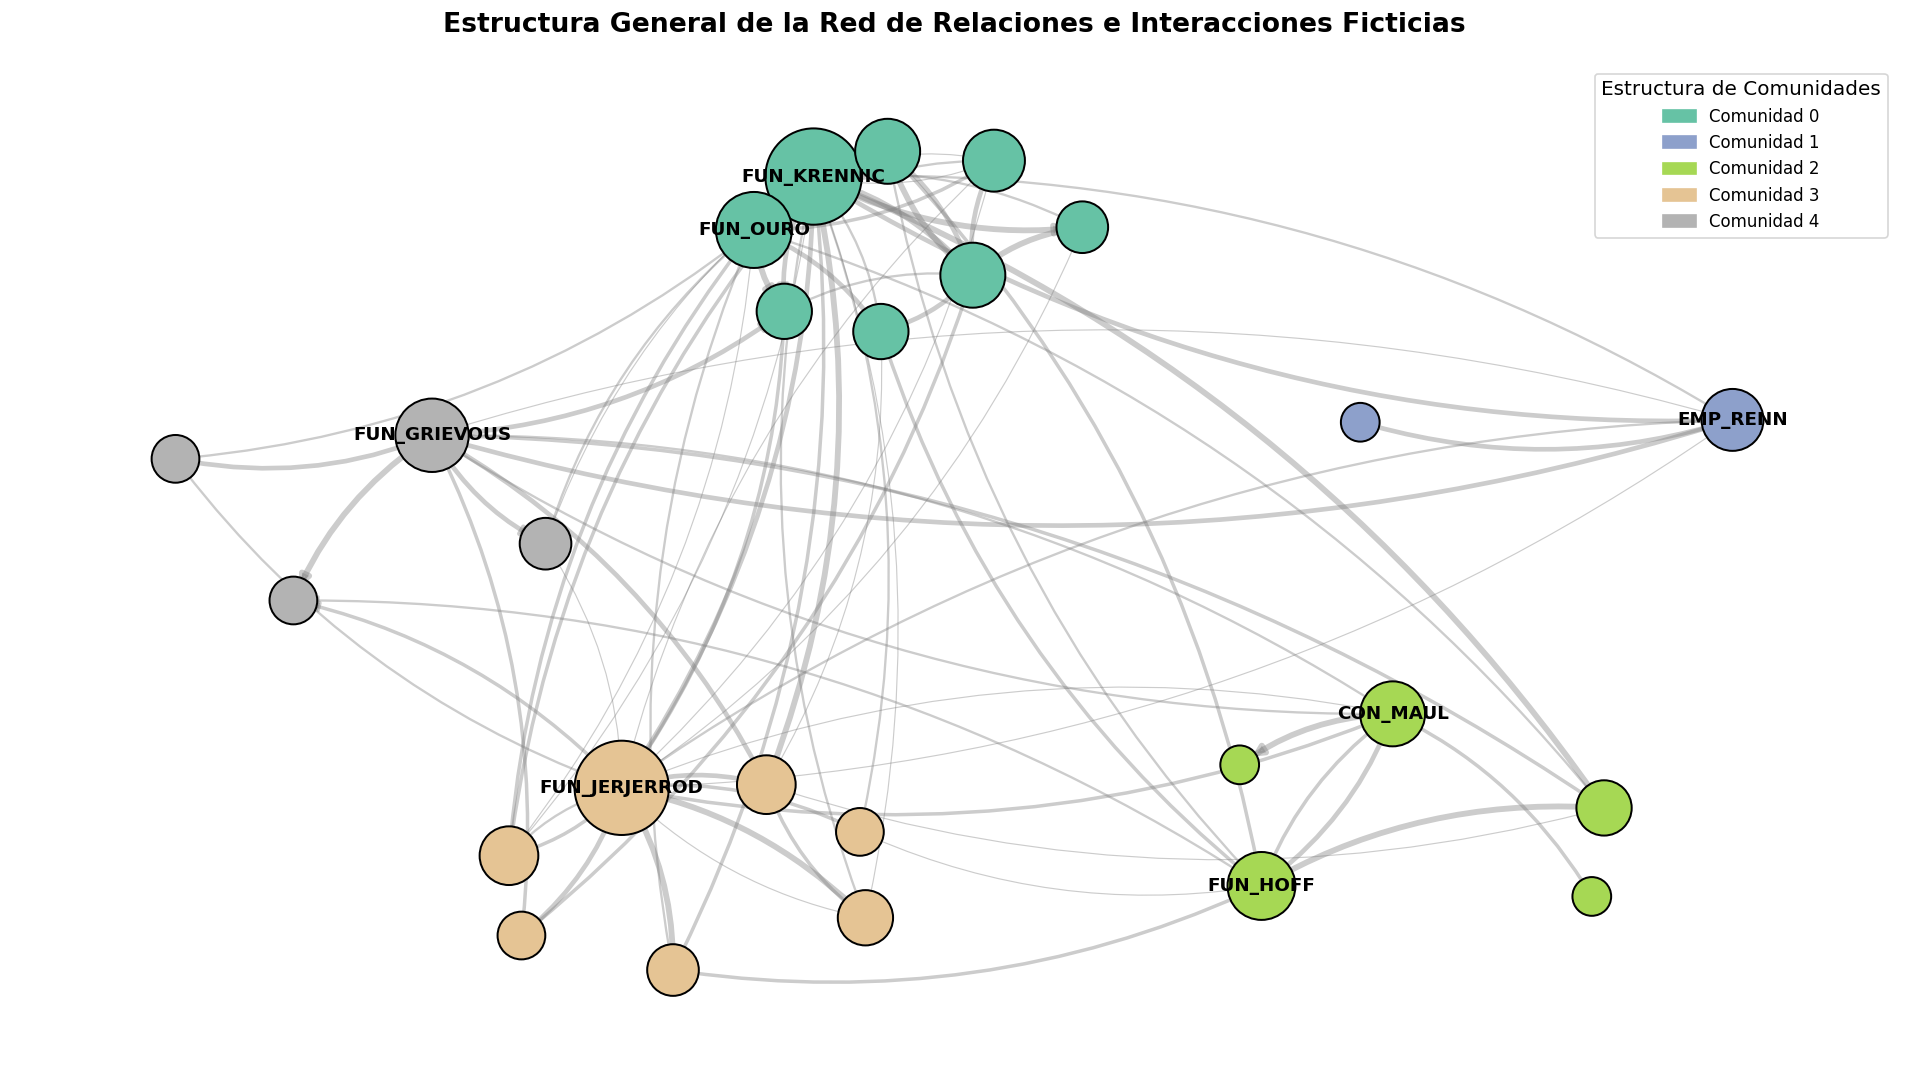

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# 1. Configurar dimensiones
fig, ax = plt.subplots(figsize=(16, 9), dpi=120)

# 2. Algoritmo de posicionamiento agrupado por comunidades (Ajustado para mayor separación)
def posicion_por_comunidades(grafo, particion, scale_global=5.0, scale_local=1.5):
    comunidades_unicas = list(set(particion.values()))
    num_comunidades = len(comunidades_unicas)
    
    # Colocar los centros de cada comunidad en un círculo amplio
    g_centros = nx.cycle_graph(num_comunidades) if num_comunidades > 2 else nx.path_graph(num_comunidades)
    centros_pos = nx.spring_layout(g_centros, scale=scale_global)
    
    pos_final = {}
    for idx, com_id in enumerate(comunidades_unicas):
        # Filtrar nodos pertenecientes a la comunidad actual
        nodos_com = [nodo for nodo, com in particion.items() if com == com_id and nodo in grafo]
        sub_g = grafo.subgraph(nodos_com)
        
        # k más alto (ej. 2.0) aumenta fuertemente la repulsión entre nodos de la misma comunidad
        pos_interna = nx.spring_layout(sub_g, k=5.0, center=centros_pos[idx], scale=scale_local, iterations=100)
        pos_final.update(pos_interna)
        
    return pos_final

# Calcular las posiciones usando la partición de Louvain previa
posiciones = posicion_por_comunidades(G, particion_louvain, scale_global=5.0, scale_local=1.5)

# 3. Configurar propiedades visuales de los nodos y aristas
comunidades = [G.nodes[n]['comunidad_detectada'] for n in G.nodes()]
num_comunidades = len(set(comunidades))

# Paleta amigable
cmap_comunidades = plt.cm.get_cmap('Set2', num_comunidades)

# El tamaño depende de la centralidad de grado
tamanos_nodos = [G.nodes[n]['degree_centrality'] * 3500 + 400 for n in G.nodes()]

# El grosor de la arista se reduce a la mitad para evitar superposición densa
pesos_aristas = [G[u][v]['peso'] * 0.7 for u, v in G.edges()]

# 4. Dibujar elementos del grafo general
# Aristas curvas (connectionstyle) con menor grosor
nx.draw_networkx_edges(G, posiciones, width=pesos_aristas, edge_color='gray', alpha=0.4, 
                       arrows=True, arrowsize=12, connectionstyle="arc3,rad=0.15", ax=ax)

# Nodos coloreados por su ID de comunidad de Louvain
nodos_dibujados = nx.draw_networkx_nodes(G, posiciones, node_size=tamanos_nodos, node_color=comunidades, 
                                         cmap=cmap_comunidades, edgecolors='black', linewidths=1.2, ax=ax)

# 5. Etiquetado exclusivo del Top 5 de centralidades
nodos_top = set(df_degree['Nodo'].tolist() + df_betweenness['Nodo'].tolist())
etiquetas_filtradas = {nodo: nodo if nodo in nodos_top else '' for nodo in G.nodes()}

nx.draw_networkx_labels(G, posiciones, labels=etiquetas_filtradas, font_size=11, 
                        font_weight='bold', font_family='sans-serif', ax=ax)

# 6. Construir la leyenda de comunidades de forma manual
parches_leyenda = []
for com_id in sorted(list(set(comunidades))):
    color = cmap_comunidades(com_id)
    parches_leyenda.append(mpatches.Patch(color=color, label=f"Comunidad {com_id}"))

ax.legend(handles=parches_leyenda, title="Estructura de Comunidades", loc="upper right", fontsize=10, title_fontsize=12)

# 7. Detalles finales de la visualización
ax.set_title("Estructura General de la Red de Relaciones e Interacciones Ficticias", fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

# Guardar en alta definición (1920x1080)
plt.tight_layout()
plt.savefig("Luengo_Antonia_T2_grafo.png", format="png", dpi=120, bbox_inches='tight')
plt.show()

### Subgrafo del Núcleo de Corrupción

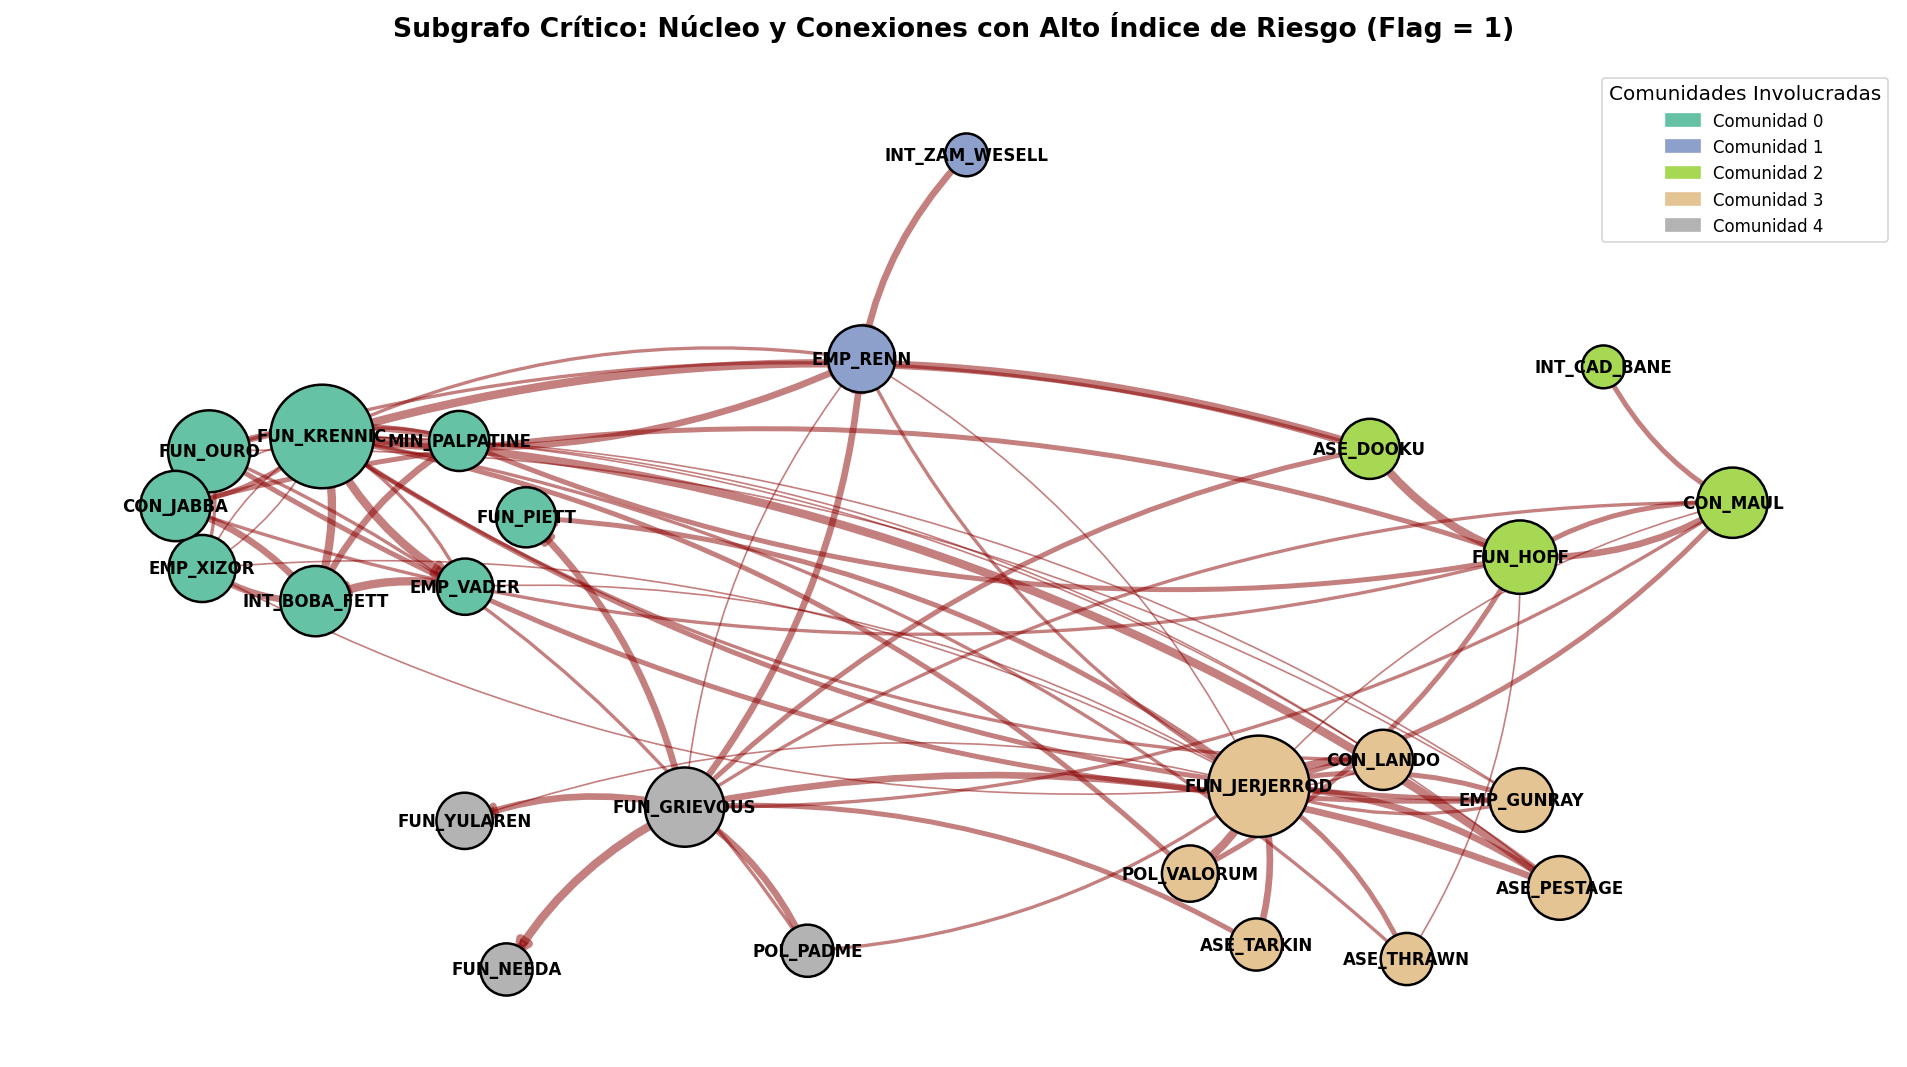

In [21]:
# 1. Configurar dimensiones
fig_sub, ax_sub = plt.subplots(figsize=(16, 9), dpi=120)

# 2. Filtrar el grafo original reteniendo únicamente los enlaces con riesgo crítico (riesgo == 1)
aristas_criticas = [(u, v) for u, v, attrs in G.edges(data=True) if attrs.get('riesgo') == 1]
G_subgrafo = G.edge_subgraph(aristas_criticas).copy()

# Recalcular las posiciones con mayor separación
particion_sub = {n: G.nodes[n]['comunidad_detectada'] for n in G_subgrafo.nodes()}
posiciones_sub = posicion_por_comunidades(G_subgrafo, particion_sub, scale_global=4.0, scale_local=1.2)

# 3. Propiedades visuales específicas del núcleo crítico
comunidades_sub = [G_subgrafo.nodes[n]['comunidad_detectada'] for n in G_subgrafo.nodes()]
tamanos_sub = [G_subgrafo.nodes[n]['degree_centrality'] * 4000 + 500 for n in G_subgrafo.nodes()]
# Reducimos el multiplicador de grosor
pesos_sub = [G_subgrafo[u][v]['peso'] * 1.0 for u, v in G_subgrafo.edges()]

# 4. Dibujar el subgrafo
# Aristas curvas para el subgrafo también
nx.draw_networkx_edges(G_subgrafo, posiciones_sub, width=pesos_sub, edge_color='#8B0000', alpha=0.5, 
                       arrows=True, arrowsize=15, connectionstyle="arc3,rad=0.15", ax=ax_sub)

nx.draw_networkx_nodes(G_subgrafo, posiciones_sub, node_size=tamanos_sub, node_color=comunidades_sub, 
                       cmap=cmap_comunidades, edgecolors='black', linewidths=1.5, ax=ax_sub)

# En el núcleo crítico mostramos etiquetas de todos los actores involucrados
etiquetas_sub = {nodo: nodo for nodo in G_subgrafo.nodes()}
nx.draw_networkx_labels(G_subgrafo, posiciones_sub, labels=etiquetas_sub, font_size=10, 
                        font_weight='bold', font_family='sans-serif', ax=ax_sub)

# 5. Leyenda y títulos
ax_sub.legend(handles=parches_leyenda, title="Comunidades Involucradas", loc="upper right", fontsize=10, title_fontsize=12)
ax_sub.set_title("Subgrafo Crítico: Núcleo y Conexiones con Alto Índice de Riesgo (Flag = 1)", fontsize=16, fontweight='bold', pad=20)
ax_sub.axis('off')

# Guardar en alta definición (1920x1080)
plt.tight_layout()
plt.savefig("Luengo_Antonia_T2_subgrafo.png", format="png", dpi=120, bbox_inches='tight')
plt.show()